# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2580s 15us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

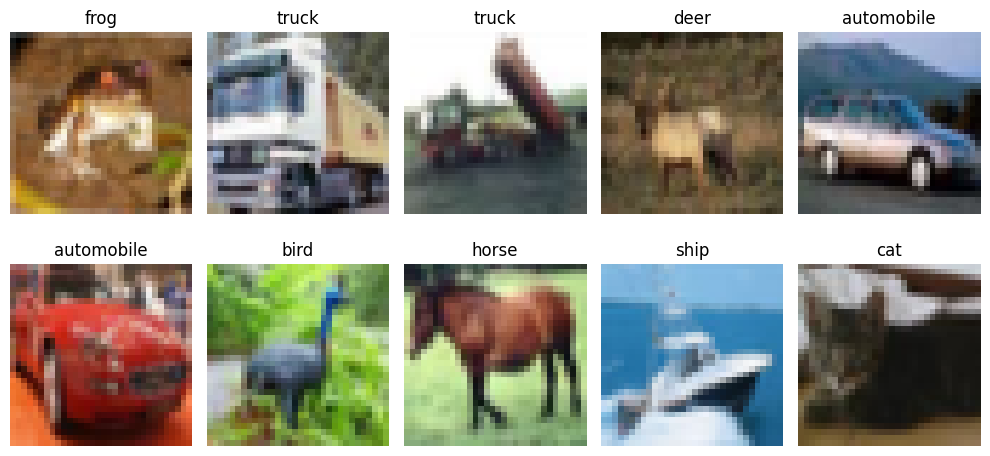

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2710 - loss: 1.9928 - val_accuracy: 0.3452 - val_loss: 1.8173
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3170 - loss: 1.8715 - val_accuracy: 0.3496 - val_loss: 1.7953
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3396 - loss: 1.8177 - val_accuracy: 0.3760 - val_loss: 1.7544
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3536 - loss: 1.7827 - val_accuracy: 0.3838 - val_loss: 1.7308
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3579 - loss: 1.7558 - val_accuracy: 0.3854 - val_loss: 1.7250
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3669 - loss: 1.7457 - val_accuracy: 0.3986 - val_loss: 1.7053
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3729 - loss: 1.7309 - val_accuracy: 0.4184 - val_loss: 1.6678
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3818 - loss: 1.7006 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4229 - loss: 1.6263
ANN Test Accuracy: 0.42289999127388


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4578 - loss: 1.5112 - val_accuracy: 0.5174 - val_loss: 1.3514
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5924 - loss: 1.1560 - val_accuracy: 0.5122 - val_loss: 1.4099
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6598 - loss: 0.9825 - val_accuracy: 0.6474 - val_loss: 0.9892
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7045 - loss: 0.8547 - val_accuracy: 0.6172 - val_loss: 1.1502
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7384 - loss: 0.7566 - val_accuracy: 0.6788 - val_loss: 0.9603
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7656 - loss: 0.6703 - val_accuracy: 0.6860 - val_loss: 0.9419
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7905 - loss: 0.6002 - val_accuracy: 0.6898 - val_loss: 0.9518
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8089 - loss: 0.5448 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7091 - loss: 0.9918
CNN Test Accuracy: 0.7091000080108643


## 📈 Compare Learning Curves

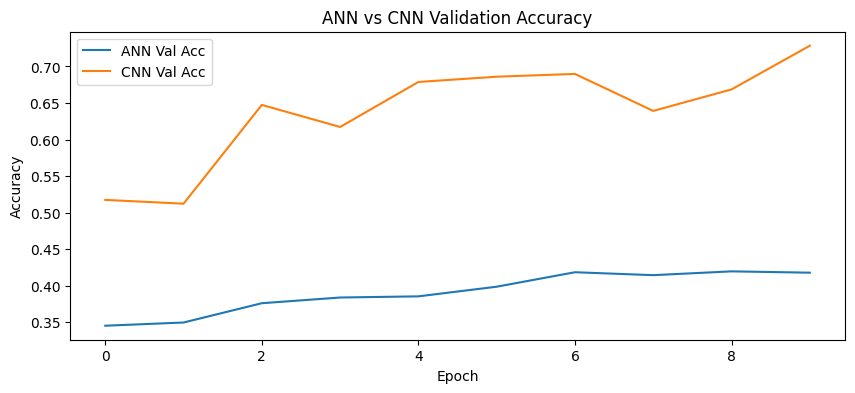

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4229
1,CNN,0.7091


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## 1. Increase ANN layers and observe performance
We widen and deepen the ANN by adding an extra Dense block.

In [12]:
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2548 - loss: 2.0172 - val_accuracy: 0.3266 - val_loss: 1.8614
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3132 - loss: 1.8759 - val_accuracy: 0.3154 - val_loss: 1.8568
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3306 - loss: 1.8251 - val_accuracy: 0.3426 - val_loss: 1.8152
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3500 - loss: 1.7903 - val_accuracy: 0.3742 - val_loss: 1.7503
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3577 - loss: 1.7632 - val_accuracy: 0.3792 - val_loss: 1.7260
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3658 - loss: 1.7430 - val_accuracy: 0.3988 - val_loss: 1.6818
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3735 - loss: 1.7238 - val_accuracy: 0.4166 - val_loss: 1.6475
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3825 - loss: 1.7083 - val_accuracy: 0.

In [13]:
deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", deep_ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4392 - loss: 1.6142
Deeper ANN Test Accuracy: 0.4392000138759613


## 2. Scale Up CNN Filters (32 → 64 → 128)
The base CNN above already uses a 32→64→128 filter progression in three conv blocks. Here we make that progression more explicit and a bit heavier by adding a second conv layer inside each block.

In [14]:
wide_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

wide_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

wide_cnn_history = wide_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.4116 - loss: 1.6239 - val_accuracy: 0.5178 - val_loss: 1.4140
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5904 - loss: 1.1570 - val_accuracy: 0.6370 - val_loss: 1.0293
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6773 - loss: 0.9361 - val_accuracy: 0.6914 - val_loss: 0.8950
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7253 - loss: 0.7953 - val_accuracy: 0.7136 - val_loss: 0.8114
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7627 - loss: 0.6888 - val_accuracy: 0.7520 - val_loss: 0.7348
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7900 - loss: 0.6087 - val_accuracy: 0.7526 - val_loss: 0.7313
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8179 - loss: 0.5336 - val_accuracy: 0.7800 - val_loss: 0.6786
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8369 - loss: 0.4742 - val_accuracy: 

In [15]:
wide_cnn_test_loss, wide_cnn_test_acc = wide_cnn_model.evaluate(x_test_norm, y_test)
print("Wide CNN (32-64-128, deeper blocks) Test Accuracy:", wide_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7934 - loss: 0.6664
Wide CNN (32-64-128, deeper blocks) Test Accuracy: 0.79339998960495


## 3. Increase epochs to 20
We train the same 32→64→128 CNN architecture for up to 20 epochs.

In [16]:
epo_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

epo_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

epo_cnn_history = epo_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.4749 - loss: 1.4695 - val_accuracy: 0.5592 - val_loss: 1.2034
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6105 - loss: 1.1089 - val_accuracy: 0.6318 - val_loss: 1.0452
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6725 - loss: 0.9419 - val_accuracy: 0.6678 - val_loss: 0.9698
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7141 - loss: 0.8218 - val_accuracy: 0.6502 - val_loss: 1.0695
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7470 - loss: 0.7290 - val_accuracy: 0.7226 - val_loss: 0.8347
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7709 - loss: 0.6526 - val_accuracy: 0.6890 - val_loss: 0.9148
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7920 - loss: 0.5921 - val_accuracy: 0.7216 - val_loss: 0.8182
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8118 - loss: 0.5251 - val_accuracy: 

In [17]:
epo_cnn_test_loss, epo_cnn_test_acc = epo_cnn_model.evaluate(x_test_norm, y_test)
print("20-Epoch CNN Test Accuracy:", epo_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7169 - loss: 1.2833
20-Epoch CNN Test Accuracy: 0.7168999910354614


## 4. EarlyStopping
we attach an EarlyStopping callback that watches validation loss and restores the best weights. This means training stops automatically once the model stops improving, instead of always running the full 20 epochs regardless of overfitting.

In [18]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

final_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

final_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_cnn_history = final_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.4753 - loss: 1.4768 - val_accuracy: 0.5020 - val_loss: 1.4660
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6101 - loss: 1.1122 - val_accuracy: 0.5462 - val_loss: 1.2862
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6725 - loss: 0.9412 - val_accuracy: 0.5628 - val_loss: 1.3507
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7142 - loss: 0.8158 - val_accuracy: 0.6536 - val_loss: 0.9691
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7459 - loss: 0.7258 - val_accuracy: 0.6894 - val_loss: 0.9279
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7696 - loss: 0.6556 - val_accuracy: 0.6358 - val_loss: 1.1584
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7956 - loss: 0.5782 - val_accuracy: 0.7058 - val_loss: 0.9240
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8164 - loss: 0.5197 - val_accuracy: 

In [19]:
final_cnn_test_loss, final_cnn_test_acc = final_cnn_model.evaluate(x_test_norm, y_test)
print("20-Epoch + EarlyStopping CNN Test Accuracy:", final_cnn_test_acc)
print("Stopped after", len(final_cnn_history.history['loss']), "epochs")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6912 - loss: 0.9916
20-Epoch + EarlyStopping CNN Test Accuracy: 0.6912000179290771
Stopped after 10 epochs


## 5. Data Augmentation Training

In [20]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3536 - loss: 1.7660 - val_accuracy: 0.4648 - val_loss: 1.4892
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4516 - loss: 1.5200 - val_accuracy: 0.5174 - val_loss: 1.3362
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4879 - loss: 1.4286 - val_accuracy: 0.5566 - val_loss: 1.2411
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5114 - loss: 1.3665 - val_accuracy: 0.5430 - val_loss: 1.2995
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5286 - loss: 1.3245 - val_accuracy: 0.5518 - val_loss: 1.2785
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5446 - loss: 1.2851 - val_accuracy: 0.6088 - val_loss: 1.1005
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5554 - loss: 1.2604 - val_accuracy: 0.5760 - val_loss: 1.2021
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5650 - loss: 1.2315 - val_accuracy: 0

## Validation Accuracy of all Models

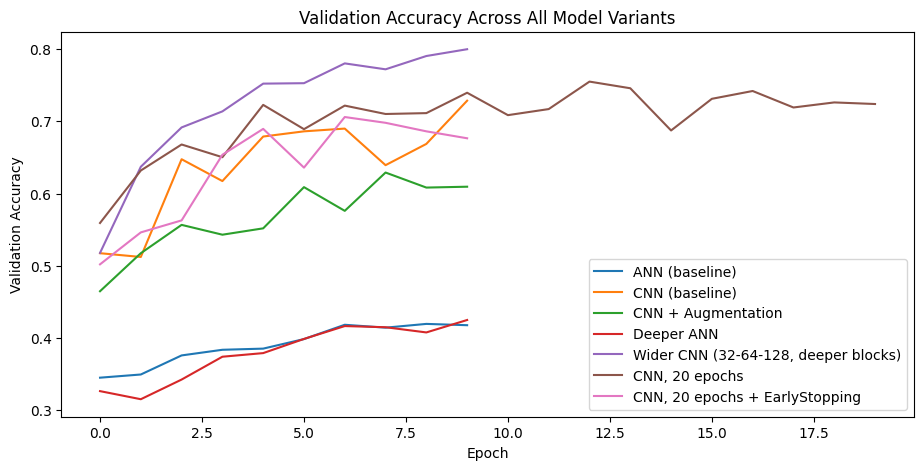

In [21]:
plt.figure(figsize=(11,5))
plt.plot(ann_history.history['val_accuracy'], label='ANN (baseline)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN (baseline)')
plt.plot(aug_history.history['val_accuracy'], label='CNN + Augmentation')
plt.plot(deep_ann_history.history['val_accuracy'], label='Deeper ANN')
plt.plot(wide_cnn_history.history['val_accuracy'], label='Wider CNN (32-64-128, deeper blocks)')
plt.plot(epo_cnn_history.history['val_accuracy'], label='CNN, 20 epochs')
plt.plot(final_cnn_history.history['val_accuracy'], label='CNN, 20 epochs + EarlyStopping')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across All Model Variants")
plt.legend()
plt.show()

## Final Comparison Table

In [22]:
full_comparison = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "CNN (baseline)",
        "CNN + Augmentation",
        "Deeper ANN",
        "Wider CNN (32-64-128, deeper blocks)",
        "CNN, 20 epochs",
        "CNN, 20 epochs + EarlyStopping"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc,
        deep_ann_test_acc,
        wide_cnn_test_acc,
        epo_cnn_test_acc,
        final_cnn_test_acc
    ]
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

full_comparison

,Model,Test Accuracy
0,"Wider CNN (32-64-128, deeper blocks)",0.7934
1,"CNN, 20 epochs",0.7169
2,CNN (baseline),0.7091
3,"CNN, 20 epochs + EarlyStopping",0.6912
4,CNN + Augmentation,0.6118
5,Deeper ANN,0.4392
6,ANN (baseline),0.4229


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**